# 용인시 인구 현황 분석 미니 프로젝트

> **주제** 내가 살고 있는 지역(경기도 용인시)의 주민등록 인구 데이터를 분석해,
> 시청·구청이 주민을 위해 어떤 정책을 우선해야 할지 근거를 만든다.

| 항목 | 내용 |
|---|---|
| 데이터 | `202512_202512_주민등록인구및세대현황_연간.csv`<br>`HangJeongDong_ver20251231.geojson` (행정동 경계) |
| 출처 | 행정안전부 주민등록 인구통계 (jumin.mois.go.kr)<br>행정동 경계: github.com/vuski/admdongkor |
| 기준 시점 | 2025년 12월 (연간 자료) |
| 공간 범위 | 경기도 용인시 — 처인구 · 기흥구 · 수지구, 39개 읍·면·동 |
| 관측치 | 43행 (시 1 + 구 3 + 읍면동 39) |
| 도구 | pandas · matplotlib · plotly · folium |

## 분석 질문 (Research Questions)

1. **규모** — 용인시 인구·세대는 어디에 얼마나 몰려 있는가? 구·동 간 격차는 얼마나 큰가?
2. **세대 구조** — 세대당 인구로 볼 때 '가족 중심 동'과 '소규모 세대 동'은 어디인가?
3. **성비** — 남녀 균형이 깨진 지역은 어디이며, 세대 구조와 어떤 관계가 있는가?
4. **공간** — 이 패턴은 지도에서 어떻게 분포하는가? 경계 자료로 면적·**인구밀도**를 붙이면 무엇이 달라지는가?
5. **유형화** — 위 지표를 조합해 39개 동을 몇 가지 정책 유형으로 묶을 수 있는가?
6. **정책** — 유형별로 시청·구청이 우선해야 할 주민 정책은 무엇인가?

## 분석 절차

`데이터 수집` → `전처리·파싱` → `현황 분석(기술통계)` → `시각화` → `공간 분석(지도·밀도)` → `지역 유형화` → `정책 시사점` → `보고서 스토리라인`

---
## 1. 환경 설정

한글 폰트는 **눈누 기초고딕 Regular**을 쓴다. `fonts/` 폴더의 TTF 파일을 matplotlib에 직접 등록하므로
OS에 폰트를 설치하지 않아도 같은 결과가 나온다. 이 폰트에 없는 글리프(`—`, `–`)는 뒤따르는 대체 폰트가 받는다.

차트 색은 **4색 팔레트**만 쓴다 — `#4285F4` 파랑 · `#0F9D58` 초록 · `#F4B400` 노랑 · `#DB4437` 빨강.
색은 취향이 아니라 **역할**로 배정한다.

| 역할 | 쓰는 색 | 쓰는 곳 |
|---|---|---|
| 범주형(정체성) | 파랑 · 초록 · 노랑 — 고정 순서 | 3개 구 구분 |
| 순차형(크기) | 파랑 단일 hue 5단 | 인구밀도 · 세대당 인구 |
| 발산형(기준선 대비) | 파랑 ↔ 중립 회색 ↔ 빨강 | 시 평균 대비 편차 · 상관행렬 |
| 스캐폴딩 | 회색 계열 | 축 · 눈금선 · 글자 — 데이터가 아닌 요소엔 브랜드 색을 쓰지 않는다 |

**색상 접근성 확인**
- 구 3색(파랑·초록·노랑)은 적/녹색약 시뮬레이션에서 최악 쌍 ΔE 14.5 (기준 8 이상) — 통과
- 파랑↔빨강 발산 쌍은 ΔE 28.3 — 통과
- 초록과 빨강은 색약에서 ΔE 4.9로 **구분되지 않는다.** 그래서 4색을 한 차트에 범주로 쓰지 않고,
  5장 지역유형 지도는 색(2색) + 마커 모양의 **복합 인코딩**으로 나눈다.
- 노랑은 밝아서 배경 대비가 1.75:1(권장 3:1 미달)이다. 노랑이 들어가는 차트는 **항상 직접 라벨이나
  바로 아래 표**로 값을 함께 읽을 수 있게 둔다.

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

# ---------- 한글 폰트: 눈누 기초고딕 Regular ----------
# 폰트 파일을 프로젝트 안에 두고 직접 등록한다 → OS 설치 여부와 무관하게 동일한 결과.
FONT_PATH = 'fonts/NoonnuBasicGothicRegular.ttf'
FONT_NAME = '눈누 기초고딕 Regular'
FALLBACK_ALL = ['NanumGothic', 'Malgun Gothic', 'AppleGothic', 'DejaVu Sans']
_installed = {f.name for f in fm.fontManager.ttflist}
FALLBACK = [f for f in FALLBACK_ALL if f in _installed]      # 없는 폰트는 빼서 findfont 경고를 없앤다

if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    FONT_STACK = [FONT_NAME] + FALLBACK      # 이 폰트에 없는 글리프(—, –)는 뒤 폰트가 대신 그린다
    print(f'폰트 등록 완료: {FONT_NAME}  ({FONT_PATH})')
else:
    FONT_STACK = FALLBACK
    print(f'{FONT_PATH} 없음 → 대체 폰트 사용: {FONT_STACK[0]}')

plt.rcParams['font.family'] = FONT_STACK
plt.rcParams['axes.unicode_minus'] = False

# 브라우저에서 그려지는 plotly·folium용 CSS 폰트 스택 + 웹폰트 정의
CSS_FONT = ', '.join(f"'{f}'" for f in [FONT_NAME] + FALLBACK_ALL) + ', sans-serif'
WEBFONT_CSS = ("@font-face{font-family:'눈누 기초고딕 Regular';"
               "src:url('https://cdn.jsdelivr.net/gh/projectnoonnu/noon-2410@1.0/"
               "NoonnuBasicGothicRegular.woff2') format('woff2');font-display:swap;}")


def inject_webfont(path):
    """저장한 HTML(plotly·folium)에 웹폰트를 심어 다른 PC에서도 같은 폰트로 열리게 한다."""
    with open(path, encoding='utf-8') as f:
        html = f.read()
    style = f'<style>{WEBFONT_CSS} body,.leaflet-container{{font-family:{CSS_FONT};}}</style>'
    with open(path, 'w', encoding='utf-8') as f:
        f.write(html.replace('</head>', style + '</head>', 1))


pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 60)
pd.set_option('display.unicode.east_asian_width', True)

폰트 등록 완료: 눈누 기초고딕 Regular  (fonts/NoonnuBasicGothicRegular.ttf)


In [2]:
# ---------- 색상 팔레트 & 차트 기본 스타일 ----------
# 4색 팔레트. 색은 '역할'로만 배정한다 — 정체성(범주형) / 크기(순차형) / 기준선 대비(발산형)
BLUE, GREEN, YELLOW, RED = '#4285F4', '#0F9D58', '#F4B400', '#DB4437'

# 중립 스캐폴딩(회색) — 축·눈금선·글자용. 데이터가 아닌 요소엔 브랜드 색을 쓰지 않는다.
SURFACE, INK, INK2, MUTED, GRID, AXIS = '#f8f9fa', '#202124', '#5f6368', '#80868b', '#dadce0', '#c4c7c5'

GU_ORDER = ['처인구', '기흥구', '수지구']
GU_COLOR = {'처인구': BLUE, '기흥구': GREEN, '수지구': YELLOW}    # 범주형 슬롯 1~3 (고정 순서, 순환 금지)

POS, NEG, NEUTRAL = BLUE, RED, '#f1f3f4'                        # 발산형: 파랑↔빨강 + 중립 회색
BLUE_RAMP = ['#8ab4f8', '#669df6', '#4285f4', '#1967d2', '#174ea6']   # 순차형 단일 hue 5단 (밝음→어두움)
DIVERGING = LinearSegmentedColormap.from_list('rd_bl', [NEG, NEUTRAL, POS])


def ink_on(bg):
    """배경색 위에 얹을 글자색을 명도로 고른다 (노랑 위 흰 글씨 방지)."""
    rgb = [int(bg.lstrip('#')[i:i + 2], 16) / 255 for i in (0, 2, 4)]
    f = lambda c: c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    lum = 0.2126 * f(rgb[0]) + 0.7152 * f(rgb[1]) + 0.0722 * f(rgb[2])
    return INK if lum > 0.4 else '#ffffff'


mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.linewidth': 0.8,
    'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',   # 실선 헤어라인 (점선 금지)
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'savefig.bbox': 'tight',
})


def grid_on(ax, axis='x'):
    """눈금선을 데이터 마크 뒤로 보내는 헬퍼."""
    ax.grid(True, axis=axis, zorder=0)
    ax.set_axisbelow(True)


MAN = FuncFormatter(lambda v, p: f'{v/10000:.0f}만')

IMG_DIR = 'images'
os.makedirs(IMG_DIR, exist_ok=True)
print('스타일 설정 완료')

스타일 설정 완료


---
## 2. 데이터 불러오기

행정안전부 주민등록 인구통계 CSV는 **CP949(euc-kr) 인코딩**이고 숫자에 천단위 콤마가 들어 있다.
`encoding='cp949'`, `thousands=','` 두 옵션으로 한 번에 해결한다.

In [3]:
CSV_PATH = '202512_202512_주민등록인구및세대현황_연간.csv'

raw = pd.read_csv(CSV_PATH, encoding='cp949', thousands=',')
print('원본 shape:', raw.shape)
print('원본 컬럼:', list(raw.columns))
raw.head()

원본 shape: (43, 7)
원본 컬럼: ['행정구역', '2025년_총인구수', '2025년_세대수', '2025년_세대당 인구', '2025년_남자 인구수', '2025년_여자 인구수', '2025년_남여 비율']


,행정구역,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,경기도 경기도 용인시 (4146000000),1091186,448730,2.43,540342,550844,0.98
1,경기도 경기도 용인시 처인구 (4146100000),282044,129138,2.18,144280,137764,1.05
2,경기도 용인시 처인구 포곡읍(4146125000),30848,14128,2.18,15939,14909,1.07
3,경기도 용인시 처인구 모현읍(4146125300),34384,15822,2.17,17726,16658,1.06
4,경기도 용인시 처인구 이동읍(4146125600),19018,8921,2.13,9773,9245,1.06


In [4]:
# 컬럼명이 '2025년_총인구수'처럼 연도 접두어가 붙어 있어 짧게 정리
raw.columns = ['행정구역', '총인구수', '세대수', '세대당인구', '남자인구수', '여자인구수', '남여비율']

print(raw.dtypes)
print()
print('결측치:', raw.isna().sum().sum(), '개')
print('중복행:', raw.duplicated().sum(), '개')
raw.describe().round(2)

행정구역          str
총인구수        int64
세대수          int64
세대당인구    float64
남자인구수      int64
여자인구수      int64
남여비율      float64
dtype: object

결측치: 0 개
중복행: 0 개


,총인구수,세대수,세대당인구,남자인구수,여자인구수,남여비율
count,43.00,43.00,43.00,43.00,43.00,43.00
mean,76129.26,31306.74,2.40,37698.28,38430.98,0.99
std,181618.27,74540.12,0.28,89867.19,91761.22,0.06
min,7477.00,3880.00,1.79,3930.00,3441.00,0.91
25%,21096.00,9140.00,2.20,10677.00,10394.50,0.95
50%,30848.00,11598.00,2.43,14852.00,14970.00,0.98
75%,37298.00,15528.50,2.60,18225.50,18727.50,1.02
max,1091186.00,448730.00,3.02,540342.00,550844.00,1.20


---
## 3. 데이터 전처리

`행정구역` 컬럼 한 칸에 **행정 계층 + 행정코드**가 뭉쳐 있다.

```
경기도 경기도 용인시 (4146000000)          ← 시
경기도 경기도 용인시 처인구 (4146100000)   ← 구
경기도 용인시 처인구 포곡읍(4146125000)    ← 읍면동
```

- 괄호 안 10자리 숫자는 **행정코드**로 분리
- `경기도 경기도`처럼 **중복 표기**를 제거
- 남은 토큰 개수로 **계층(시/구/읍면동)** 을 판정하고 `구`, `동` 컬럼을 만든다

> 이렇게 계층을 분리해두면 **시 합계 행이 구·동 집계에 이중 계상되는 실수**를 막을 수 있다.

In [5]:
def parse_region(name):
    """'경기도 경기도 용인시 처인구 (4146100000)' -> ('4146100000', ['경기도','용인시','처인구'])"""
    m = re.match(r'^(.*?)\s*\((\d+)\)$', name.strip())
    label, code = m.group(1).strip(), m.group(2)
    tokens = []
    for t in label.split():
        if not tokens or tokens[-1] != t:      # 연속 중복 토큰('경기도 경기도') 제거
            tokens.append(t)
    return code, tokens


# 파싱 결과 확인
for s in raw['행정구역'].head(3):
    print(f'{s:45s} -> {parse_region(s)}')

경기도 경기도 용인시 (4146000000)                      -> ('4146000000', ['경기도', '용인시'])
경기도 경기도 용인시 처인구 (4146100000)                  -> ('4146100000', ['경기도', '용인시', '처인구'])
경기도 용인시 처인구 포곡읍(4146125000)                   -> ('4146125000', ['경기도', '용인시', '처인구', '포곡읍'])


In [6]:
parsed = raw['행정구역'].apply(parse_region)
df = raw.copy()
df['행정코드'] = parsed.str[0]
tokens = parsed.str[1]

# 토큰 개수로 계층 판정: 2개=시, 3개=구, 4개=읍면동
df['구분'] = tokens.apply(lambda t: {2: '시', 3: '구'}.get(len(t), '읍면동'))
df['구'] = tokens.apply(lambda t: t[2] if len(t) >= 3 else None)
df['동'] = tokens.apply(lambda t: t[3] if len(t) >= 4 else None)

print(df['구분'].value_counts().to_string())
df[['행정코드', '구분', '구', '동', '총인구수', '세대수']].head(8)

구분
읍면동    39
구         3
시         1


,행정코드,구분,구,동,총인구수,세대수
0,4146000000,시,NaN,NaN,1091186,448730
1,4146100000,구,처인구,NaN,282044,129138
2,4146125000,읍면동,처인구,포곡읍,30848,14128
3,4146125300,읍면동,처인구,모현읍,34384,15822
4,4146125600,읍면동,처인구,이동읍,19018,8921
5,4146125900,읍면동,처인구,남사읍,23561,9999
6,4146134000,읍면동,처인구,원삼면,7477,3880
7,4146135000,읍면동,처인구,백암면,7584,4226


In [7]:
# 계층별로 테이블 분리
city = df[df['구분'] == '시'].iloc[0]
gu   = df[df['구분'] == '구'].set_index('구').loc[GU_ORDER].copy()
dong = df[df['구분'] == '읍면동'].reset_index(drop=True).copy()

# ---------- 파생변수 ----------
for t in (gu, dong):
    t['성비'] = t['남자인구수'] / t['여자인구수'] * 100        # 여자 100명당 남자 수
    t['여성비율'] = t['여자인구수'] / t['총인구수'] * 100
    t['시_인구비중'] = t['총인구수'] / city['총인구수'] * 100

dong['유형'] = np.select(
    [dong['동'].str.endswith('읍'), dong['동'].str.endswith('면')],
    ['읍', '면'], default='동')
dong['세대당인구_편차'] = dong['세대당인구'] - city['세대당인구']

# 검증: 구 합계와 시 합계가 일치해야 한다
print('인구 검증:', gu['총인구수'].sum(), '==', city['총인구수'], '->', gu['총인구수'].sum() == city['총인구수'])
print('세대 검증:', gu['세대수'].sum(), '==', city['세대수'], '->', gu['세대수'].sum() == city['세대수'])
print('동 합계 인구:', f"{dong['총인구수'].sum():,}")

dong[['구', '동', '유형', '총인구수', '세대수', '세대당인구', '성비', '시_인구비중']].head()

인구 검증: 1091186 == 1091186 -> True
세대 검증: 448730 == 448730 -> True
동 합계 인구: 1,091,186


,구,동,유형,총인구수,세대수,세대당인구,성비,시_인구비중
0,처인구,포곡읍,읍,30848,14128,2.18,106.908579,2.827016
1,처인구,모현읍,읍,34384,15822,2.17,106.411334,3.151067
2,처인구,이동읍,읍,19018,8921,2.13,105.711195,1.742874
3,처인구,남사읍,읍,23561,9999,2.36,102.483671,2.159210
4,처인구,원삼면,면,7477,3880,1.93,110.797857,0.685218


---
## 4. 현황 분석

### 4.1 용인시 전체 한눈에 보기

단일 값 요약은 차트보다 **숫자 그 자체**가 더 잘 읽힌다 (KPI 카드 형태로 출력).

In [8]:
sex_ratio = city['남자인구수'] / city['여자인구수'] * 100

print('=' * 62)
print(f"{'용인시 인구 현황 (2025년 12월 기준)':^54}")
print('=' * 62)
print(f"  총인구수        {city['총인구수']:>12,} 명")
print(f"  세대수          {city['세대수']:>12,} 세대")
print(f"  세대당 인구     {city['세대당인구']:>12.2f} 명")
print(f"  남자            {city['남자인구수']:>12,} 명  ({city['남자인구수']/city['총인구수']*100:.1f}%)")
print(f"  여자            {city['여자인구수']:>12,} 명  ({city['여자인구수']/city['총인구수']*100:.1f}%)")
print(f"  성비            {sex_ratio:>12.1f}     (여자 100명당 남자)")
print(f"  행정동 수       {len(dong):>12,} 개  (동 {(dong['유형']=='동').sum()} / 읍 {(dong['유형']=='읍').sum()} / 면 {(dong['유형']=='면').sum()})")
print('=' * 62)
print(f"  ※ 인구 100만 명을 넘는 '특례시' 규모. 여자가 남자보다 {city['여자인구수']-city['남자인구수']:,}명 많다.")

               용인시 인구 현황 (2025년 12월 기준)               
  총인구수           1,091,186 명
  세대수               448,730 세대
  세대당 인구             2.43 명
  남자                 540,342 명  (49.5%)
  여자                 550,844 명  (50.5%)
  성비                    98.1     (여자 100명당 남자)
  행정동 수                 39 개  (동 32 / 읍 4 / 면 3)
  ※ 인구 100만 명을 넘는 '특례시' 규모. 여자가 남자보다 10,502명 많다.


### 4.2 구별 비교

용인시는 3개 구로 나뉜다. 전체 대비 각 구의 몫(부분-전체)은 **100% 누적 가로 막대**로 본다.

In [9]:
gu_summary = gu[['총인구수', '세대수', '세대당인구', '남자인구수', '여자인구수', '성비', '여성비율', '시_인구비중']]
gu_summary.round(2)

,총인구수,세대수,세대당인구,남자인구수,여자인구수,성비,여성비율,시_인구비중
구,,,,,,,,
처인구,282044,129138,2.18,144280,137764,104.73,48.84,25.85
기흥구,435048,177169,2.46,214142,220906,96.94,50.78,39.87
수지구,374094,142423,2.63,181920,192174,94.66,51.37,34.28


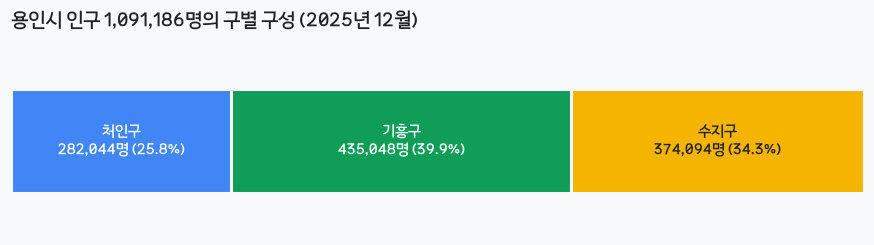

In [10]:
fig, ax = plt.subplots(figsize=(10, 2.2))

left = 0
for g in GU_ORDER:
    w = gu.loc[g, '시_인구비중']
    ax.barh(0, w, left=left, height=0.5, color=GU_COLOR[g], label=g,
            edgecolor=SURFACE, linewidth=2)          # 2px 서피스 간격으로 세그먼트 구분
    ax.text(left + w / 2, 0, f"{g}\n{gu.loc[g, '총인구수']:,}명 ({w:.1f}%)",
            ha='center', va='center', color=ink_on(GU_COLOR[g]), fontsize=10)   # 노랑 위엔 검은 글씨
    left += w

ax.set_xlim(0, 100); ax.set_ylim(-0.45, 0.45)
ax.set_yticks([]); ax.set_xticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f"용인시 인구 {city['총인구수']:,}명의 구별 구성 (2025년 12월)",
             fontsize=13, pad=14, loc='left', color=INK)

fig.savefig(f'{IMG_DIR}/01_구별구성.png')
plt.show()

**읽기** — 기흥구가 43.5만 명(39.9%)으로 가장 크고, 수지구 37.4만 명(34.3%), 처인구 28.2만 명(25.8%) 순이다.
그런데 **면적을 생각하면 이야기가 뒤집힌다.** 처인구는 용인시 면적의 대부분을 차지하는데 인구는 4분의 1뿐이다.
즉 처인구는 넓고 인구가 흩어진 지역, 기흥·수지구는 좁고 밀집한 지역이다.
(※ 이 CSV에는 면적 정보가 없다. 이 문장은 여기서는 아직 외부 지식이며, **4.8절에서 행정동 경계 자료를 붙여 면적·인구밀도를 직접 계산해 검증한다.**)

### 4.3 읍·면·동별 인구 분포

39개 행정동은 이름만 나열하면 비교가 안 된다. **정렬한 가로 막대**로 순위와 격차를 함께 본다.
막대 색은 크기가 아니라 **소속 구(정체성)** 를 나타낸다.

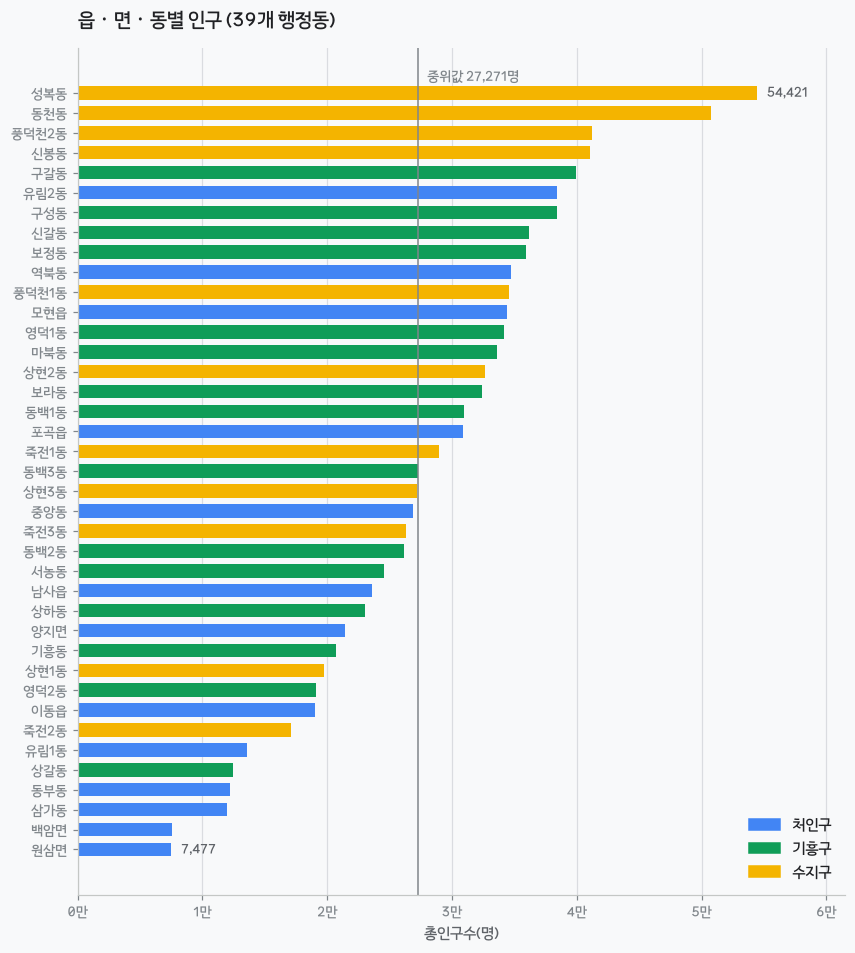

In [11]:
d = dong.sort_values('총인구수')
med = dong['총인구수'].median()

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(d['동'], d['총인구수'], color=[GU_COLOR[g] for g in d['구']], height=0.68)
grid_on(ax, 'x')
ax.xaxis.set_major_formatter(MAN)
ax.set_xlim(0, dong['총인구수'].max() * 1.13)

# 중위값 기준선 (선택적 직접 레이블)
ax.axvline(med, color=MUTED, lw=1, zorder=1)
ax.annotate(f'중위값 {med:,.0f}명', xy=(med, len(d) - 0.2), xytext=(6, 0),
            textcoords='offset points', color=MUTED, fontsize=9, va='center')

# 최댓값 · 최솟값만 직접 레이블
for name in [d['동'].iloc[-1], d['동'].iloc[0]]:
    r = dong[dong['동'] == name].iloc[0]
    ax.text(r['총인구수'] + med * 0.03, list(d['동']).index(name), f"{r['총인구수']:,}",
            va='center', fontsize=9, color=INK2)

handles = [plt.Rectangle((0, 0), 1, 1, color=GU_COLOR[g]) for g in GU_ORDER]
ax.legend(handles, GU_ORDER, frameon=False, loc='lower right', fontsize=10)
ax.set_title('읍 · 면 · 동별 인구 (39개 행정동)', fontsize=13, pad=14, loc='left', color=INK)
ax.set_xlabel('총인구수(명)')

fig.savefig(f'{IMG_DIR}/02_동별인구.png')
plt.show()

In [12]:
s = dong['총인구수'].sort_values(ascending=False)
top, bot = dong.loc[s.index[0]], dong.loc[s.index[-1]]

print('── 인구 집중도 ─────────────────────────────')
print(f"  상위  5개 동 비중 : {s.head(5).sum() / s.sum() * 100:5.1f}%")
print(f"  상위 10개 동 비중 : {s.head(10).sum() / s.sum() * 100:5.1f}%   (전체 39개 중 26%)")
print(f"  하위 10개 동 비중 : {s.tail(10).sum() / s.sum() * 100:5.1f}%")
print(f"  최대/최소 격차    : {top['총인구수'] / bot['총인구수']:5.1f}배"
      f"  ({top['구']} {top['동']} {top['총인구수']:,}명 vs {bot['구']} {bot['동']} {bot['총인구수']:,}명)")
print(f"  중위값            : {med:,.0f}명 / 평균 {dong['총인구수'].mean():,.0f}명")
print()
print('── 인구 상위 10개 동 ───────────────────────')
print(dong.nlargest(10, '총인구수')[['구', '동', '총인구수', '세대수', '세대당인구', '성비']]
      .round(2).to_string(index=False))
print()
print('── 인구 하위 10개 동 ───────────────────────')
print(dong.nsmallest(10, '총인구수')[['구', '동', '총인구수', '세대수', '세대당인구', '성비']]
      .round(2).to_string(index=False))

── 인구 집중도 ─────────────────────────────
  상위  5개 동 비중 :  20.8%
  상위 10개 동 비중 :  37.7%   (전체 39개 중 26%)
  하위 10개 동 비중 :  12.9%
  최대/최소 격차    :   7.3배  (수지구 성복동 54,421명 vs 처인구 원삼면 7,477명)
  중위값            : 27,271명 / 평균 27,979명

── 인구 상위 10개 동 ───────────────────────
    구        동  총인구수  세대수  세대당인구   성비
수지구    성복동     54421   18723        2.91  92.67
수지구    동천동     50787   19711        2.58  96.09
수지구 풍덕천2동     41219   15395        2.68  96.92
수지구    신봉동     41065   14748        2.78  93.53
기흥구    구갈동     39961   18017        2.22 102.25
처인구   유림2동     38396   14906        2.58 101.18
기흥구    구성동     38395   15336        2.50  92.10
기흥구    신갈동     36201   16005        2.26  99.37
기흥구    보정동     35947   13552        2.65  95.68
처인구    역북동     34727   15696        2.21 101.89

── 인구 하위 10개 동 ───────────────────────
    구      동  총인구수  세대수  세대당인구   성비
처인구  원삼면      7477    3880        1.93 110.80
처인구  백암면      7584    4226        1.79 120.40
처인구  삼가동     11941    4767        2.50  98.45
처인구

**읽기** — 상위 10개 동(전체의 26%)에 인구의 **37.7%** 가 모여 있고, 1위 성복동(54,421명)과
최하위 원삼면(7,477명)의 격차는 **7.3배**다. 상위권은 수지구·기흥구 동이 독점하고,
하위권은 대부분 처인구의 읍·면이다. 같은 '용인시민'이라도 **행정 서비스 수요의 밀도가 완전히 다르다.**

### 4.4 세대 구조 — 세대당 인구

세대당 인구는 **가구 형태를 읽는 대리지표**다.
- 높다(2.7명↑) → 자녀가 있는 가족 세대 비중이 높다 → 보육·교육·통학·놀이터 수요
- 낮다(2.0명↓) → 1~2인 세대 비중이 높다 → 청년/노인 1인가구 돌봄, 소형주택, 생활안전 수요

시 평균(2.43명)을 기준선으로 놓고 **발산형 막대**로 편차를 본다.

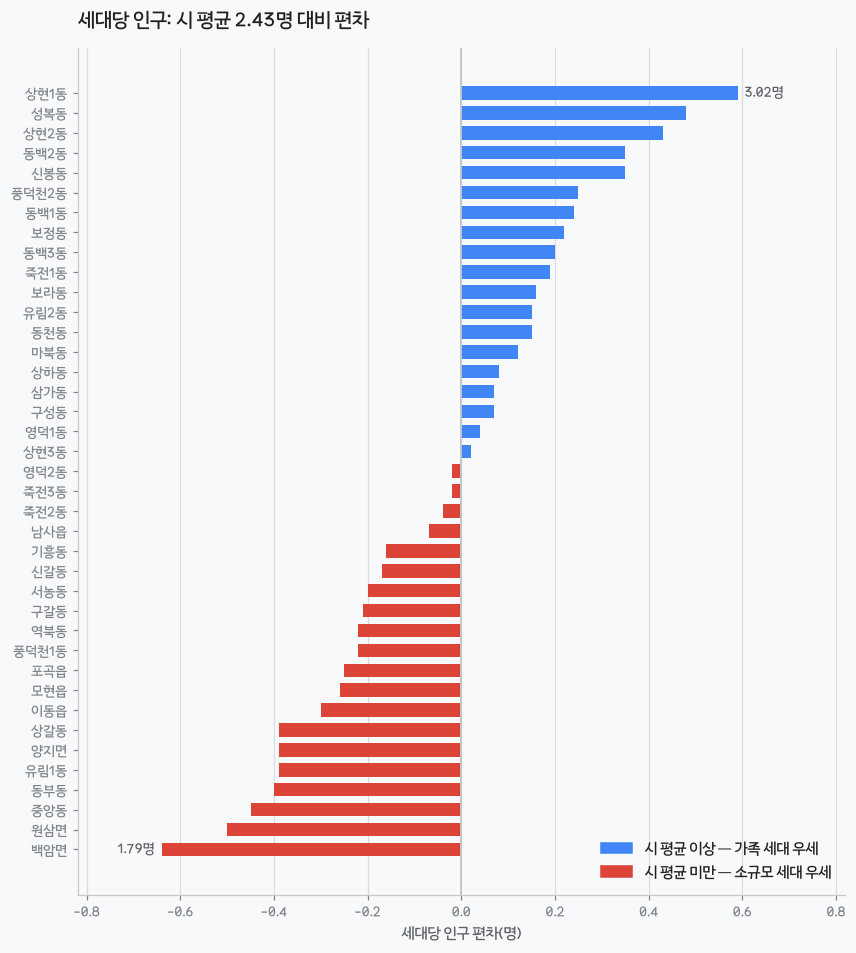

In [13]:
d = dong.sort_values('세대당인구_편차')
lim = dong['세대당인구_편차'].abs().max() * 1.28

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(d['동'], d['세대당인구_편차'],
        color=[POS if v >= 0 else NEG for v in d['세대당인구_편차']], height=0.68)
ax.axvline(0, color=AXIS, lw=1.2)
grid_on(ax, 'x')
ax.set_xlim(-lim, lim)

# 양 끝 극단값만 직접 레이블 (막대 밖에 배치해 잘림 방지)
for name in [d['동'].iloc[-1], d['동'].iloc[0]]:
    r = dong[dong['동'] == name].iloc[0]
    dv = r['세대당인구_편차']
    ax.text(dv + (0.015 if dv > 0 else -0.015), list(d['동']).index(name),
            f"{r['세대당인구']:.2f}명", va='center',
            ha='left' if dv > 0 else 'right', fontsize=9, color=INK2)

h = [plt.Rectangle((0, 0), 1, 1, color=POS), plt.Rectangle((0, 0), 1, 1, color=NEG)]
ax.legend(h, ['시 평균 이상 — 가족 세대 우세', '시 평균 미만 — 소규모 세대 우세'],
          frameon=False, loc='lower right', fontsize=10)
ax.set_title(f"세대당 인구: 시 평균 {city['세대당인구']}명 대비 편차",
             fontsize=13, pad=14, loc='left', color=INK)
ax.set_xlabel('세대당 인구 편차(명)')

fig.savefig(f'{IMG_DIR}/03_세대당인구편차.png')
plt.show()

In [14]:
print('── 세대당 인구 상위 5 (가족 세대 밀집) ──')
print(dong.nlargest(5, '세대당인구')[['구', '동', '총인구수', '세대수', '세대당인구']].to_string(index=False))
print()
print('── 세대당 인구 하위 5 (소규모 세대 밀집) ──')
print(dong.nsmallest(5, '세대당인구')[['구', '동', '총인구수', '세대수', '세대당인구']].to_string(index=False))
print()
print('── 구별 세대당 인구 ──')
print(gu[['세대당인구']].round(2).to_string())
print(f"\n  시 전체 {city['세대당인구']:.2f}명 / 동별 최대 {dong['세대당인구'].max():.2f} · "
      f"최소 {dong['세대당인구'].min():.2f} (격차 {dong['세대당인구'].max() - dong['세대당인구'].min():.2f}명)")

── 세대당 인구 상위 5 (가족 세대 밀집) ──
    구      동  총인구수  세대수  세대당인구
수지구 상현1동     19740    6534        3.02
수지구  성복동     54421   18723        2.91
수지구 상현2동     32659   11413        2.86
기흥구 동백2동     26164    9412        2.78
수지구  신봉동     41065   14748        2.78

── 세대당 인구 하위 5 (소규모 세대 밀집) ──
    구     동  총인구수  세대수  세대당인구
처인구 백암면      7584    4226        1.79
처인구 원삼면      7477    3880        1.93
처인구 중앙동     26885   13588        1.98
처인구 동부동     12230    6038        2.03
처인구 양지면     21455   10517        2.04

── 구별 세대당 인구 ──
        세대당인구
구                
처인구        2.18
기흥구        2.46
수지구        2.63

  시 전체 2.43명 / 동별 최대 3.02 · 최소 1.79 (격차 1.23명)


**읽기** — 상위권은 수지구 상현1동(3.02명)·성복동(2.91명)·상현2동(2.86명), 기흥구 동백2동(2.78명)처럼
**대단지 아파트 신도시**다. 하위권은 처인구 백암면(1.79명)·원삼면(1.93명)·중앙동(1.98명)으로
**농촌 지역과 원도심**이다. 구 평균도 수지 2.63 > 기흥 2.46 > 처인 2.18으로 뚜렷하게 갈린다.

### 4.5 성비와 세대 구조의 관계

성비(여자 100명당 남자)가 100보다 크면 남자가, 작으면 여자가 많다.
세대당 인구와 함께 놓으면 **한 장으로 지역 성격이 드러난다.**
원 크기는 인구 규모, 색은 소속 구, 점선 대신 실선 기준선은 각 지표의 평균이다.

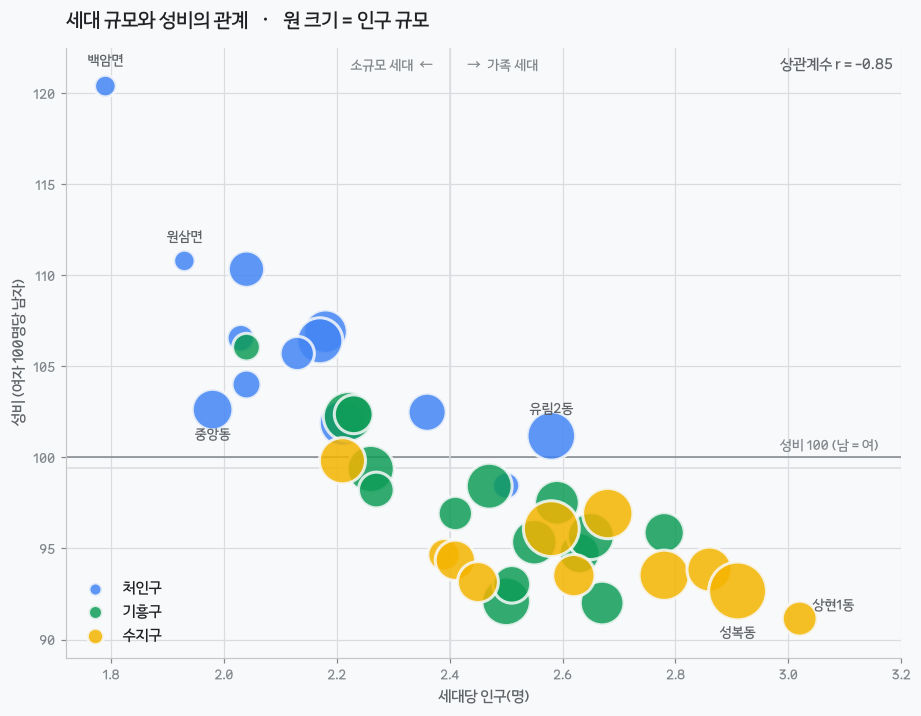

In [15]:
mh, mr = dong['세대당인구'].mean(), dong['성비'].mean()

fig, ax = plt.subplots(figsize=(9.8, 7.2))
ax.axvline(mh, color=GRID, lw=1); ax.axhline(mr, color=GRID, lw=1)
ax.axhline(100, color=MUTED, lw=1, zorder=1)

for g in GU_ORDER:
    s = dong[dong['구'] == g]
    ax.scatter(s['세대당인구'], s['성비'], s=s['총인구수'] / 38, color=GU_COLOR[g],
               alpha=0.85, edgecolor=SURFACE, linewidth=2, label=g, zorder=3)
grid_on(ax, 'both')

# 이야기를 만드는 지점만 선택적으로 라벨링 (오프셋 수동 지정으로 충돌 방지)
ax.set_xlim(1.72, 3.20); ax.set_ylim(89, 122.5)      # 라벨 놓을 여백 확보
LABELS = {'백암면': (0, 14), '원삼면': (0, 13), '중앙동': (0, -19),
          '유림2동': (0, 15), '성복동': (0, -30), '상현1동': (22, 6)}
for name, off in LABELS.items():
    r = dong[dong['동'] == name].iloc[0]
    ax.annotate(name, (r['세대당인구'], r['성비']), textcoords='offset points',
                xytext=off, ha='center', fontsize=9, color=INK2)

ax.text(mh - 0.03, ax.get_ylim()[1] - 1.2, '소규모 세대  ←', ha='right', fontsize=9, color=MUTED)
ax.text(mh + 0.03, ax.get_ylim()[1] - 1.2, '→  가족 세대', ha='left', fontsize=9, color=MUTED)
ax.annotate('성비 100 (남 = 여)', xy=(3.16, 100), xytext=(0, 5), ha='right',
            textcoords='offset points', fontsize=9, color=MUTED)
ax.text(0.99, 0.965, f"상관계수 r = {dong['세대당인구'].corr(dong['성비']):.2f}",
        transform=ax.transAxes, ha='right', fontsize=10, color=INK2)

ax.set_xlabel('세대당 인구(명)'); ax.set_ylabel('성비 (여자 100명당 남자)')
ax.set_title('세대 규모와 성비의 관계   ·   원 크기 = 인구 규모', fontsize=13, pad=14, loc='left', color=INK)
ax.legend(frameon=False, loc='lower left', fontsize=10, scatterpoints=1, markerscale=0.35)

fig.savefig(f'{IMG_DIR}/04_사분면.png')
plt.show()

In [16]:
print('── 성비 상위 5 (남자 많음) ──')
print(dong.nlargest(5, '성비')[['구', '동', '총인구수', '성비', '세대당인구']].round(2).to_string(index=False))
print()
print('── 성비 하위 5 (여자 많음) ──')
print(dong.nsmallest(5, '성비')[['구', '동', '총인구수', '성비', '세대당인구']].round(2).to_string(index=False))
print()
print(f"성비 100 초과(남자 우위) 동: {(dong['성비'] > 100).sum()}개 / 100 미만(여자 우위) 동: {(dong['성비'] < 100).sum()}개")

── 성비 상위 5 (남자 많음) ──
    구     동  총인구수   성비  세대당인구
처인구 백암면      7584 120.40        1.79
처인구 원삼면      7477 110.80        1.93
처인구 양지면     21455 110.34        2.04
처인구 포곡읍     30848 106.91        2.18
처인구 동부동     12230 106.55        2.03

── 성비 하위 5 (여자 많음) ──
    구      동  총인구수  성비  세대당인구
수지구 상현1동     19740 91.15        3.02
기흥구 동백1동     30995 92.00        2.67
기흥구  구성동     38395 92.10        2.50
수지구  성복동     54421 92.67        2.91
기흥구  상하동     22988 93.03        2.51

성비 100 초과(남자 우위) 동: 15개 / 100 미만(여자 우위) 동: 24개


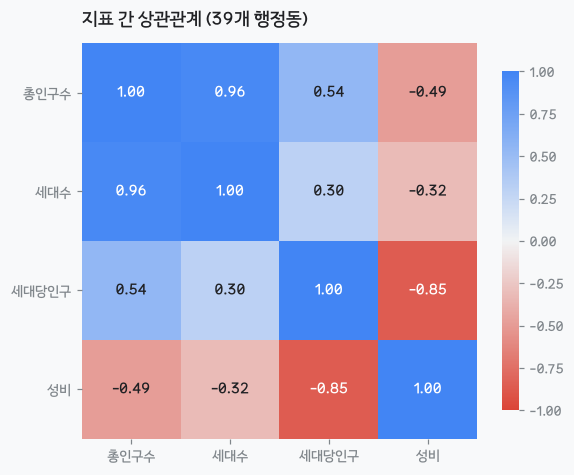

,총인구수,세대수,세대당인구,성비
총인구수,1.000,0.958,0.538,-0.488
세대수,0.958,1.000,0.303,-0.316
세대당인구,0.538,0.303,1.000,-0.853
성비,-0.488,-0.316,-0.853,1.000


In [17]:
cols = ['총인구수', '세대수', '세대당인구', '성비']
corr = dong[cols].corr()

fig, ax = plt.subplots(figsize=(5.8, 5.0))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)     # 발산형: 중간값은 중립 회색
ax.set_xticks(range(len(cols)), cols)
ax.set_yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                color=ink_on(mpl.colors.to_hex(DIVERGING((v + 1) / 2))))
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.outline.set_visible(False); cb.ax.tick_params(color=MUTED, labelcolor=MUTED)
ax.set_title('지표 간 상관관계 (39개 행정동)', fontsize=12, pad=12, loc='left', color=INK)

fig.savefig(f'{IMG_DIR}/05_상관관계.png')
plt.show()
corr.round(3)

**읽기 — 이 프로젝트의 핵심 발견**

세대당 인구와 성비의 상관계수는 **r = −0.85**로 매우 강한 음의 관계다.
즉 **가족 세대가 많은 동일수록 여자가 많고, 소규모 세대가 많은 동일수록 남자가 많다.**

- 성비가 가장 높은 곳: 처인구 백암면(120.4) · 원삼면(110.8) · 양지면(110.3)
  → 농촌·산업단지 지역으로, 세대당 인구도 1.8~2.0명대. **1인 남성 세대(산업단지 근로자 등)** 가 많은 구조로 읽힌다.
- 성비가 가장 낮은 곳: 수지구 상현1동(91.2) · 기흥구 동백1동(92.0) · 구성동(92.1)
  → 세대당 인구 2.5~3.0명의 대단지 아파트. 여성·아동 인구가 두터운 **가족 정착 지역**이다.

인구 규모와 성비도 r = −0.49로 음의 관계여서, **작은 동일수록 성비 불균형이 심하다.**

### 4.6 읍 · 면 · 동 유형별 비교

행정동 이름 끝의 '읍/면/동'은 그 자체로 도시화 정도를 담고 있다. 세 지표를 **소형 다중 패널**로 나란히 본다.

      개수  인구합  평균인구  평균세대당인구  평균성비
유형                                                  
동      32  946859  29589.34            2.47     97.32
읍       4  107811  26952.75            2.21    105.38
면       3   36516  12172.00            1.92    113.85


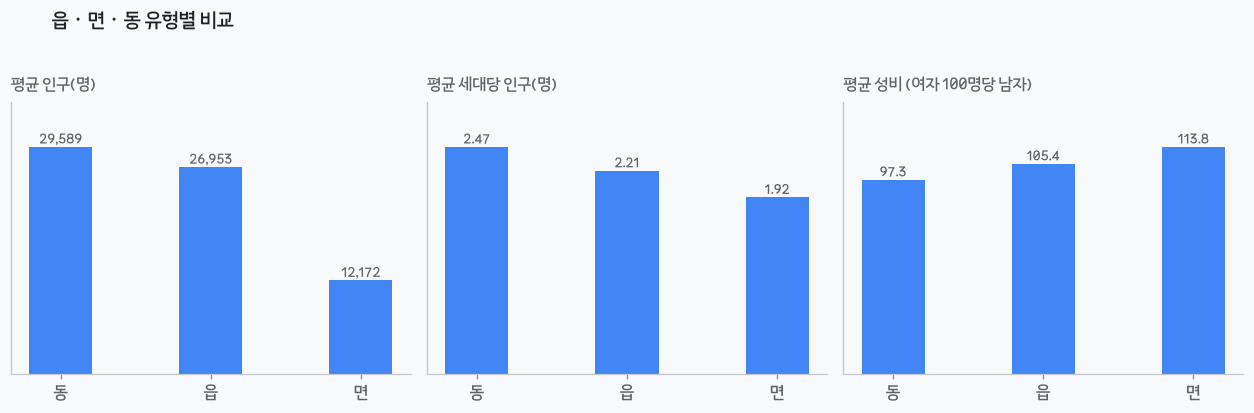

In [18]:
by_type = (dong.groupby('유형')
           .agg(개수=('동', 'count'), 인구합=('총인구수', 'sum'), 평균인구=('총인구수', 'mean'),
                평균세대당인구=('세대당인구', 'mean'), 평균성비=('성비', 'mean'))
           .reindex(['동', '읍', '면']))
print(by_type.round(2).to_string())

metrics = [('평균인구', '평균 인구(명)', lambda v: f'{v:,.0f}'),
           ('평균세대당인구', '평균 세대당 인구(명)', lambda v: f'{v:.2f}'),
           ('평균성비', '평균 성비 (여자 100명당 남자)', lambda v: f'{v:.1f}')]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
for ax, (col, title, fmt) in zip(axes, metrics):
    ax.bar(by_type.index, by_type[col], color=BLUE_RAMP[2], width=0.42)   # 순차형 단일 hue, 얇은 막대
    grid_on(ax, 'y')
    for x, v in zip(by_type.index, by_type[col]):
        ax.text(x, v, fmt(v), ha='center', va='bottom', fontsize=9, color=INK2)
    ax.set_title(title, fontsize=10.5, color=INK2, loc='left', pad=8)
    ax.set_yticks([]); ax.margins(y=0.2)
    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=11, color=INK2)

fig.suptitle('읍 · 면 · 동 유형별 비교', fontsize=13, ha='left', x=0.045, y=1.03, color=INK)
fig.tight_layout()
fig.savefig(f'{IMG_DIR}/06_유형별.png')
plt.show()

**읽기** — 32개 '동'은 평균 29,589명 / 세대당 2.47명 / 성비 97.3인데,
3개 '면'은 평균 12,172명 / 세대당 1.92명 / 성비 **113.9**다.
면 지역은 인구가 동의 41% 수준인데 성비 불균형은 압도적으로 크다. 읍은 그 중간에 위치한 **전이 지대**다.

### 4.7 인터랙티브 시각화 (plotly)

정적 차트로는 39개 동을 한 번에 다 라벨링할 수 없다. plotly의 **호버 툴팁**으로
모든 값을 읽을 수 있게 만들어 보완한다. (툴팁은 보조 수단이고, 위의 표에 값이 모두 있다.)

In [19]:
import plotly.express as px
import plotly.io as pio

# 기본값은 application/vnd.plotly.v1+json 으로 나가서 전용 렌더러 없으면 빈칸이 된다.
# notebook_connected = plotly.js를 CDN에서 불러오는 HTML로 출력 → VSCode·브라우저 모두 표시.
pio.renderers.default = 'notebook_connected'

# ① 트리맵 — 구 > 동 계층의 인구 규모
tm = px.treemap(
    dong, path=[px.Constant('용인시'), '구', '동'], values='총인구수',
    color='세대당인구', color_continuous_scale=[BLUE_RAMP[0], BLUE_RAMP[2], BLUE_RAMP[4]],  # 순차형 단일 hue
    range_color=(dong['세대당인구'].min(), dong['세대당인구'].max()),
    custom_data=['세대수', '성비'],
    title='용인시 인구 트리맵 — 크기 = 인구, 색 = 세대당 인구')
tm.update_traces(
    marker_line_color=SURFACE, marker_line_width=2,
    hovertemplate='<b>%{label}</b><br>인구 %{value:,}명<br>세대 %{customdata[0]:,}세대'
                  '<br>세대당 %{color:.2f}명<br>성비 %{customdata[1]:.1f}<extra></extra>')
tm.update_layout(width=980, height=520, paper_bgcolor=SURFACE,
                 font=dict(family=CSS_FONT, size=12, color=INK),
                 margin=dict(t=60, l=10, r=10, b=10),
                 coloraxis_colorbar=dict(title='세대당<br>인구'))
tm.write_html(f'{IMG_DIR}/07_트리맵.html')
inject_webfont(f'{IMG_DIR}/07_트리맵.html')
tm.show()

In [20]:
# ② 인터랙티브 버블 차트 — 4.5절 산점도의 호버 버전
sc = px.scatter(
    dong, x='세대당인구', y='성비', size='총인구수', color='구',
    color_discrete_map=GU_COLOR, category_orders={'구': GU_ORDER},
    size_max=48, hover_name='동',
    hover_data={'총인구수': ':,', '세대수': ':,', '세대당인구': ':.2f', '성비': ':.1f', '구': False},
    labels={'세대당인구': '세대당 인구(명)', '성비': '성비 (여자 100명당 남자)'},
    title='세대 규모 vs 성비 (마우스를 올려 동별 값 확인)')
sc.add_hline(y=100, line_width=1, line_color=MUTED)
sc.add_vline(x=mh, line_width=1, line_color=GRID)
sc.add_hline(y=mr, line_width=1, line_color=GRID)
sc.update_traces(marker=dict(line=dict(color=SURFACE, width=2)))
sc.update_layout(width=980, height=560, paper_bgcolor=SURFACE, plot_bgcolor=SURFACE,
                 font=dict(family=CSS_FONT, size=12, color=INK),
                 legend=dict(title='', orientation='h', y=-0.16),
                 xaxis=dict(gridcolor=GRID, zeroline=False),
                 yaxis=dict(gridcolor=GRID, zeroline=False),
                 hovermode='closest', margin=dict(t=60, l=60, r=20, b=60))
sc.write_html(f'{IMG_DIR}/08_버블차트.html')
inject_webfont(f'{IMG_DIR}/08_버블차트.html')
sc.show()

### 4.8 공간 분석 — folium 단계구분도

여기까지의 차트는 **"어느 동이 큰가"** 만 말한다. 4.2절에서 이미 걸림돌이 하나 나왔다.
"처인구는 넓다"는 서술을 원본 CSV로는 뒷받침할 수 없었다는 점이다.
**행정동 경계 GeoJSON**을 붙이면 두 가지가 한 번에 해결된다.

1. **위치** — 인구·세대·성비 패턴이 공간적으로 이어져 있는지(=실재하는 지역 성격인지) 확인한다.
2. **면적** — 경계 폴리곤에서 면적을 계산해 **인구밀도**라는 새 지표를 만든다.
   (원본 CSV에 면적이 없어 9장 후속 과제로 남겨두었던 항목이다.)

| 항목 | 내용 |
|---|---|
| 경계 자료 | `HangJeongDong_ver20251231.geojson` (행정안전부 행정동 경계) |
| 출처 | github.com/vuski/admdongkor |
| 기준 시점 | 2025-12-31 — **인구 데이터와 같은 시점** |
| 조인 키 | 10자리 `행정코드` (`adm_cd2`) ↔ 인구 CSV의 행정코드 |
| 도구 | folium(Leaflet.js) + branca 색상 척도 |

> **경계는 시점을 맞춰야 한다.** 용인시는 2025년에 유림동이 유림1·2동으로 분동됐다.
> 2025-04 버전 경계로는 38개만 매칭돼 한 개 동이 지도에서 조용히 사라진다.
> 같은 시점(2025-12-31) 경계를 써야 39개가 1:1로 붙는다. 아래 셀에서 그 조인을 검증한다.

In [21]:
import json
import math
import urllib.request

import folium
import branca.colormap as bcm

# ---------- 행정동 경계 GeoJSON ----------
# 출처: vuski/admdongkor (행정안전부 행정동 경계, 2025-12-31 기준 — 인구 데이터와 같은 시점)
GEO_PATH = 'geo/용인시_행정동.geojson'
GEO_URL = ('https://raw.githubusercontent.com/vuski/admdongkor/master/'
           'ver20251231/HangJeongDong_ver20251231.geojson')


def load_yongin_geo(path=GEO_PATH, url=GEO_URL):
    """용인시 39개 행정동 경계만 잘라 캐시해두고 재사용한다 (전국 파일은 35MB)."""
    if os.path.exists(path):
        with open(path, encoding='utf-8') as f:
            return json.load(f)

    print('전국 행정동 경계 다운로드 중...')
    with urllib.request.urlopen(url) as r:
        nation = json.loads(r.read().decode('utf-8'))

    def rnd(o, p=5):                                     # 좌표 5자리(약 1m) → 파일 크기 1/5
        if isinstance(o, list):
            return [rnd(x, p) for x in o]
        return round(o, p) if isinstance(o, float) else o

    feats = []
    for f in nation['features']:
        pr = f['properties']
        if '용인시' not in pr.get('adm_nm', ''):
            continue
        feats.append({'type': 'Feature',
                      'properties': {'행정코드': pr['adm_cd2'],
                                     '동': pr['adm_nm'].split()[-1],
                                     '구': pr['sggnm'].replace('용인시', '')},
                      'geometry': {'type': f['geometry']['type'],
                                   'coordinates': rnd(f['geometry']['coordinates'])}})
    geo = {'type': 'FeatureCollection', 'features': feats}
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(geo, f, ensure_ascii=False)
    print(f'저장: {path} ({os.path.getsize(path)/1024:.0f} KB, {len(feats)}개 동)')
    return geo


geo = load_yongin_geo()

# ---------- 조인 검증: 행정코드 기준으로 39개가 1:1로 붙어야 한다 ----------
geo_codes = {f['properties']['행정코드'] for f in geo['features']}
csv_codes = set(dong['행정코드'])
print(f'GeoJSON {len(geo_codes)}개 / CSV {len(csv_codes)}개 '
      f'/ 교집합 {len(geo_codes & csv_codes)}개 -> 조인 {"성공" if geo_codes == csv_codes else "실패"}')
print('CSV에만 있음:', sorted(csv_codes - geo_codes) or '없음',
      '| GeoJSON에만 있음:', sorted(geo_codes - csv_codes) or '없음')

GeoJSON 39개 / CSV 39개 / 교집합 39개 -> 조인 성공
CSV에만 있음: 없음 | GeoJSON에만 있음: 없음


In [22]:
# ---------- 경계에서 면적 · 중심점 계산 (원본 CSV에 없는 정보) ----------
R = 6371.0088                                   # 지구 반지름(km)
LAT0 = 37.24                                    # 용인시 중심 위도 — 국지 등면적 근사의 기준

def _ring_area_centroid(ring):
    """경위도 링 하나의 부호 있는 면적(km^2)과 무게중심. 국지 평면 근사(오차 <1%)."""
    xs = [math.radians(lon) * R * math.cos(math.radians(LAT0)) for lon, lat in ring]
    ys = [math.radians(lat) * R for lon, lat in ring]
    a = cx = cy = 0.0
    for i in range(len(ring) - 1):
        cross = xs[i] * ys[i + 1] - xs[i + 1] * ys[i]
        a += cross
        cx += (xs[i] + xs[i + 1]) * cross
        cy += (ys[i] + ys[i + 1]) * cross
    a /= 2.0
    if a == 0:
        return 0.0, None
    cx, cy = cx / (6 * a), cy / (6 * a)
    lat = math.degrees(cy / R)
    lon = math.degrees(cx / (R * math.cos(math.radians(LAT0))))
    return a, (lat, lon)


def area_centroid(geometry):
    """MultiPolygon 전체 면적(구멍은 차감)과, 가장 큰 조각의 중심점을 돌려준다."""
    polys = geometry['coordinates'] if geometry['type'] == 'MultiPolygon' else [geometry['coordinates']]
    total, best_area, best_c = 0.0, 0.0, None
    for poly in polys:
        outer, c = _ring_area_centroid(poly[0])
        outer = abs(outer)
        holes = sum(abs(_ring_area_centroid(r)[0]) for r in poly[1:])
        total += outer - holes
        if outer > best_area:
            best_area, best_c = outer, c
    return total, best_c


geo_info = {}
for f in geo['features']:
    a, c = area_centroid(f['geometry'])
    geo_info[f['properties']['행정코드']] = {'면적': a, '위도': c[0], '경도': c[1]}

dong['면적'] = dong['행정코드'].map(lambda c: geo_info[c]['면적'])
dong['위도'] = dong['행정코드'].map(lambda c: geo_info[c]['위도'])
dong['경도'] = dong['행정코드'].map(lambda c: geo_info[c]['경도'])
dong['인구밀도'] = dong['총인구수'] / dong['면적']

# 면적 검증: 용인시 공식 면적은 591.3 km^2 (용인시 통계연보)
print(f"경계 면적 합계 {dong['면적'].sum():.1f} km²  (공식 591.3 km² 대비 "
      f"{dong['면적'].sum()/591.3*100:.1f}%)")
print()
print('── 구별 면적 · 인구밀도 ──')
gu_area = (dong.groupby('구').agg(면적=('면적', 'sum'), 인구=('총인구수', 'sum'))
           .reindex(GU_ORDER)
           .assign(면적비중=lambda t: t['면적'] / t['면적'].sum() * 100,
                   인구밀도=lambda t: t['인구'] / t['면적']))
print(gu_area.round(1).to_string())
print()
print('── 인구밀도 상위 5 ──')
print(dong.nlargest(5, '인구밀도')[['구', '동', '총인구수', '면적', '인구밀도']].round(1).to_string(index=False))
print()
print('── 인구밀도 하위 5 ──')
print(dong.nsmallest(5, '인구밀도')[['구', '동', '총인구수', '면적', '인구밀도']].round(1).to_string(index=False))
print(f"\n최대/최소 밀도 격차: {dong['인구밀도'].max()/dong['인구밀도'].min():,.0f}배")

경계 면적 합계 592.0 km²  (공식 591.3 km² 대비 100.1%)

── 구별 면적 · 인구밀도 ──
         면적    인구  면적비중  인구밀도
구                                       
처인구  467.9  282044      79.0     602.8
기흥구   81.8  435048      13.8    5317.9
수지구   42.3  374094       7.2    8834.3

── 인구밀도 상위 5 ──
    구        동  총인구수  면적  인구밀도
수지구   상현1동     19740   0.9   22702.1
수지구 풍덕천2동     41219   1.8   22542.5
수지구 풍덕천1동     34599   1.6   21167.5
수지구   상현2동     32659   1.6   20747.9
기흥구   동백3동     27271   1.5   18670.5

── 인구밀도 하위 5 ──
    구     동  총인구수  면적  인구밀도
처인구 백암면      7584  65.7     115.4
처인구 원삼면      7477  60.1     124.4
처인구 이동읍     19018  76.0     250.1
처인구 양지면     21455  57.8     371.5
처인구 남사읍     23561  58.4     403.3

최대/최소 밀도 격차: 197배


**읽기 — 4.2절의 "면적을 생각하면 이야기가 뒤집힌다"를 이제 숫자로 말할 수 있다**

| | 처인구 | 기흥구 | 수지구 |
|---|---|---|---|
| 면적 | **467.9 km² (79.0%)** | 81.8 km² (13.8%) | 42.3 km² (7.2%) |
| 인구 비중 | 25.8% | 39.9% | 34.3% |
| 인구밀도 | **603명/km²** | 5,318명/km² | **8,834명/km²** |

- 처인구는 시 면적의 **79%** 를 쓰면서 인구는 **26%** 뿐이다. 수지구와 밀도 차이는 **14.7배**.
- 동 단위 격차는 **197배** — 수지구 상현1동 22,702명/km² vs 처인구 백암면 115명/km².
- 계산한 경계 면적 합계는 592.0 km²로, 용인시 공식 면적 591.3 km²와 **0.1% 차이**다.
  (경위도를 국지 평면으로 근사한 계산이므로, 이 대조가 곧 검증이다.)

밀도는 **정책 단가를 가르는 변수**다. 1km² 안에 수지구는 2만 명이 살지만 백암면은 100명대가 산다.
같은 도서관·보건소·버스 노선을 놓을 때 1인당 비용이 두 자릿수 배로 달라진다.

In [23]:
# ---------- 지도 공통 헬퍼 ----------
CENTER = [dong['위도'].mean(), dong['경도'].mean()]
TIP_STYLE = (f'background-color:{SURFACE}; border:1px solid {AXIS}; border-radius:3px; '
             f'box-shadow:2px 2px 4px rgba(0,0,0,.12); padding:6px 8px; color:{INK}; '
             f'font-size:12px; font-family:{CSS_FONT};')

# 툴팁에 쓸 표시용 문자열을 경계 속성에 붙인다 (지도 3장이 공유)
_idx = dong.set_index('행정코드')
for f in geo['features']:
    r = _idx.loc[f['properties']['행정코드']]
    f['properties'].update({
        '구·동': f"{r['구']} {r['동']}",
        '인구': f"{r['총인구수']:,}명",
        '세대': f"{r['세대수']:,}세대",
        '면적_t': f"{r['면적']:.1f} km²",
        '인구밀도_t': f"{r['인구밀도']:,.0f}명/km²",
        '세대당인구_t': f"{r['세대당인구']:.2f}명",
        '성비_t': f"{r['성비']:.1f}",
    })


def base_map():
    m = folium.Map(location=CENTER, tiles='cartodbpositron',      # 줌은 아래 fit_bounds가 결정
                   control_scale=True, width='100%', height=620,
                   scrollWheelZoom=False)   # 휠은 노트북 스크롤에 양보 (줌은 +/- 버튼)
    m.fit_bounds([[dong['위도'].min() - 0.03, dong['경도'].min() - 0.03],
                  [dong['위도'].max() + 0.03, dong['경도'].max() + 0.03]])
    folium.Element(f'<style>{WEBFONT_CSS} .leaflet-container,.legend'
                   f'{{font-family:{CSS_FONT};}}</style>').add_to(m.get_root().header)
    return m


def choropleth(m, value_col, cmap, name, tip_fields, tip_aliases):
    """행정코드로 값을 붙여 색칠하는 GeoJson 레이어."""
    vals = dong.set_index('행정코드')[value_col].to_dict()

    def style(feat):
        v = vals[feat['properties']['행정코드']]
        return {'fillColor': cmap(v), 'color': SURFACE, 'weight': 1.2, 'fillOpacity': 0.88}

    folium.GeoJson(
        geo, name=name, style_function=style,
        highlight_function=lambda f: {'weight': 3, 'color': INK, 'fillOpacity': 0.95},
        tooltip=folium.GeoJsonTooltip(fields=tip_fields, aliases=tip_aliases,
                                      sticky=False, style=TIP_STYLE)).add_to(m)


TIP_F = ['구·동', '인구', '세대', '면적_t', '인구밀도_t', '세대당인구_t', '성비_t']
TIP_A = ['', '인구', '세대수', '면적', '인구밀도', '세대당 인구', '성비']

# ================= 지도 ① 인구 규모와 밀도 =================
# 밀도는 최대/최소가 197배로 극단적으로 치우쳐 있어 선형 색상 척도로는 상위 몇 개만 보인다.
# 5분위(quintile) 구간으로 나눠 순차형 색을 배분한다.
q = dong['인구밀도'].quantile([0, .2, .4, .6, .8, 1]).tolist()
dens_cmap = bcm.StepColormap(BLUE_RAMP, index=q, vmin=q[0], vmax=q[-1],
                             caption='인구밀도 (명/km²) — 5분위 구간')

m1 = base_map()
choropleth(m1, '인구밀도', dens_cmap, '인구밀도 (색)', TIP_F, TIP_A)

# 인구 규모는 밀도와 다른 이야기를 한다 → 면적 비례 원을 별도 레이어로 겹친다
pop_layer = folium.FeatureGroup(name='인구 규모 (원 크기) · 소속 구(색)', show=True)
for _, r in dong.iterrows():
    folium.CircleMarker(
        location=[r['위도'], r['경도']],
        radius=math.sqrt(r['총인구수']) / 20,          # 면적 ∝ 인구 (지름 아님)
        color=SURFACE, weight=1.5,
        fill=True, fill_color=GU_COLOR[r['구']], fill_opacity=0.75,
        tooltip=folium.Tooltip(
            f"<b>{r['구']} {r['동']}</b><br>인구 {r['총인구수']:,}명"
            f"<br>밀도 {r['인구밀도']:,.0f}명/km²<br>면적 {r['면적']:.1f} km²",
            style=TIP_STYLE),
    ).add_to(pop_layer)
pop_layer.add_to(m1)

dens_cmap.add_to(m1)
folium.LayerControl(collapsed=False).add_to(m1)
m1.save(f'{IMG_DIR}/09_지도_인구밀도.html')
inject_webfont(f'{IMG_DIR}/09_지도_인구밀도.html')
m1

**읽기 — 지도 ①**

- 짙은 파랑(고밀도)이 **북서쪽 수지구 → 서쪽 중앙 기흥구** 로 이어지는 하나의 띠를 만든다.
  서울·분당과 맞닿은 방향이며, 행정 경계가 아니라 **개발 축**을 따라간다.
- 반대로 **동쪽·남쪽(처인구 원삼·백암·이동·남사)** 은 가장 밝은 색으로 넓게 펼쳐져 있다.
- 원(인구 규모)과 색(밀도)이 **엇갈리는 곳**이 정책적으로 흥미롭다.
  처인구 남사읍(23,561명)·양지면(21,455명)은 원이 꽤 큰데 색은 최하위 구간(400명/km² 안팎)이다.
  **인구가 적은 게 아니라 넓게 흩어져 있는** 유형 — 시설 배치보다 이동·접근성이 먼저인 지역이다.

레이어 컨트롤(우측 상단)에서 원 레이어를 끄면 밀도만, 켜면 규모와 밀도를 겹쳐 볼 수 있다.

In [24]:
# ---------- 밀도를 지표로 추가하면 무엇이 새로 보이는가 ----------
# 밀도는 115 ~ 22,702로 197배 범위라 선형 상관은 상위 몇 개 동에 끌려간다.
# 로그를 씌운 밀도(= 도시화 정도의 대리지표)로 함께 비교한다.
print('── 인구밀도와 다른 지표의 상관계수 (n=39) ──')
print(f"{'지표':>12s}   선형 밀도    log10(밀도)")
for col in ['총인구수', '세대수', '세대당인구', '성비']:
    r_lin = dong['인구밀도'].corr(dong[col])
    r_log = np.log10(dong['인구밀도']).corr(dong[col])
    print(f'{col:>12s}   {r_lin:+8.2f}   {r_log:+8.2f}')

print()
print('── 읍·면·동 유형별 면적과 밀도 ──')
print(dong.groupby('유형')
      .agg(개수=('동', 'count'), 인구=('총인구수', 'sum'), 면적=('면적', 'sum'),
           평균밀도=('인구밀도', 'mean'))
      .reindex(['동', '읍', '면'])
      .assign(면적비중=lambda t: t['면적'] / t['면적'].sum() * 100,
              인구비중=lambda t: t['인구'] / t['인구'].sum() * 100)
      .round(1).to_string())

── 인구밀도와 다른 지표의 상관계수 (n=39) ──
          지표   선형 밀도    log10(밀도)
        총인구수      +0.31      +0.51
         세대수      +0.20      +0.40
       세대당인구      +0.56      +0.67
          성비      -0.56      -0.80

── 읍·면·동 유형별 면적과 밀도 ──
      개수    인구   면적  평균밀도  면적비중  인구비중
유형                                                   
동      32  946859  181.9    8589.1      30.7      86.8
읍       4  107811  226.6     518.6      38.3       9.9
면       3   36516  183.6     203.8      31.0       3.3


In [25]:
# ================= 지도 ② 세대 구조 — 세대당 인구 =================
# 4.4절 발산형 막대와 같은 지표를 공간에 올린다. 기준선은 시 평균(2.43명).
lo, hi = dong['세대당인구'].min(), dong['세대당인구'].max()
hh_cmap = bcm.LinearColormap(BLUE_RAMP, vmin=lo, vmax=hi,
                             caption=f'세대당 인구(명) — 시 평균 {city["세대당인구"]:.2f}명')

m2 = base_map()
choropleth(m2, '세대당인구', hh_cmap, '세대당 인구', TIP_F, TIP_A)

# 시 평균 이상/이하만 구분해 읽고 싶을 때를 위한 보조 레이어 (기본 꺼짐)
above = folium.FeatureGroup(name=f'시 평균({city["세대당인구"]:.2f}명) 이상 동 표시', show=False)
for _, r in dong[dong['세대당인구'] >= city['세대당인구']].iterrows():
    folium.CircleMarker([r['위도'], r['경도']], radius=5, color=INK, weight=2,
                        fill=True, fill_color=SURFACE, fill_opacity=0.95,   # 파랑 램프 위라 색 대신 테두리로
                        tooltip=folium.Tooltip(f"<b>{r['동']}</b> 세대당 {r['세대당인구']:.2f}명",
                                               style=TIP_STYLE)).add_to(above)
above.add_to(m2)

hh_cmap.add_to(m2)
folium.LayerControl(collapsed=False).add_to(m2)
m2.save(f'{IMG_DIR}/10_지도_세대당인구.html')
inject_webfont(f'{IMG_DIR}/10_지도_세대당인구.html')
m2

**읽기 — 지도 ②와 밀도 상관**

- **log10(밀도) ↔ 성비 r = −0.80.** 4.5절의 '세대당 인구 ↔ 성비(r = −0.85)'와 거의 같은 세기다.
  즉 *밀집한 곳일수록 여성 우위, 흩어진 곳일수록 남성 우위* 라는 **도농 축이 이 데이터의 실질적 1번 축**이다.
  세대당 인구·성비·밀도 세 지표가 사실상 같은 하나의 구조를 다른 각도로 재는 셈이다.
- 밀도는 선형(r = −0.56)보다 로그(r = −0.80)에서 훨씬 뚜렷해진다. 197배 범위를 가진 지표는
  **로그 스케일로 봐야** 관계가 드러난다는 실무 교훈이기도 하다.
- 지도 ②에서 짙은 파랑(세대당 인구 높음)은 수지구 상현·성복, 기흥구 동백 일대에 **뭉쳐 있다** —
  대단지 아파트가 붙어 있는 구역이다. 같은 기흥구 안에서도 동백3동(2.6명)과 상갈·구갈동(2.2명)이 갈린다.
  세대 구조는 행정 경계보다 **개발 시기·주택 유형**을 따라간다.

---
## 5. 지역 유형화 — 39개 동을 4가지 정책 유형으로

세대당 인구(평균 2.40명)와 성비(평균 99.4)를 각각 기준선으로 잡아 사분면을 만들면,
39개 동이 **정책 성격이 다른 4개 그룹**으로 정리된다.

In [26]:
def classify(r):
    fam = '가족중심' if r['세대당인구'] >= mh else '소규모세대'
    sex = '남성우위' if r['성비'] >= mr else '여성우위'
    return f'{fam}·{sex}'

dong['지역유형'] = dong.apply(classify, axis=1)

summary = (dong.groupby('지역유형')
           .agg(동수=('동', 'count'), 인구=('총인구수', 'sum'),
                평균세대당인구=('세대당인구', 'mean'), 평균성비=('성비', 'mean'))
           .assign(인구비중=lambda t: t['인구'] / dong['총인구수'].sum() * 100)
           .sort_values('인구', ascending=False))
print(summary.round(2).to_string())
print()
for name, g in dong.groupby('지역유형'):
    members = ', '.join(f"{r['구']} {r['동']}" for _, r in g.sort_values('총인구수', ascending=False).iterrows())
    print(f"[{name}] {len(g)}개")
    print(f"  {members}\n")

                     동수    인구  평균세대당인구  평균성비  인구비중
지역유형                                                             
가족중심·여성우위      20  635442            2.63     94.76     58.23
소규모세대·남성우위    15  343300            2.10    105.91     31.46
소규모세대·여성우위     3   74048            2.31     97.41      6.79
가족중심·남성우위       1   38396            2.58    101.18      3.52

[가족중심·남성우위] 1개
  처인구 유림2동

[가족중심·여성우위] 20개
  수지구 성복동, 수지구 동천동, 수지구 풍덕천2동, 수지구 신봉동, 기흥구 구성동, 기흥구 보정동, 기흥구 영덕1동, 기흥구 마북동, 수지구 상현2동, 기흥구 보라동, 기흥구 동백1동, 수지구 죽전1동, 기흥구 동백3동, 수지구 상현3동, 수지구 죽전3동, 기흥구 동백2동, 기흥구 상하동, 수지구 상현1동, 기흥구 영덕2동, 처인구 삼가동

[소규모세대·남성우위] 15개
  기흥구 구갈동, 처인구 역북동, 수지구 풍덕천1동, 처인구 모현읍, 처인구 포곡읍, 처인구 중앙동, 기흥구 서농동, 처인구 남사읍, 처인구 양지면, 처인구 이동읍, 처인구 유림1동, 기흥구 상갈동, 처인구 동부동, 처인구 백암면, 처인구 원삼면

[소규모세대·여성우위] 3개
  기흥구 신갈동, 기흥구 기흥동, 수지구 죽전2동



In [27]:
# ================= 지도 ③ 지역유형 4분면을 공간에 =================
# 4색으로 칠하지 않는다 — 초록과 빨강은 색약 시뮬레이션에서 ΔE 4.9로 구분되지 않는다(1장).
# 대신 두 축을 나눠 인코딩한다: 면 색 = 세대 구조(파랑↔노랑, ΔE 34.3) / 마커 모양 = 성비 축.
dong['세대구조'] = np.where(dong['세대당인구'] >= mh, '가족중심', '소규모세대')
dong['성비구분'] = np.where(dong['성비'] >= mr, '남성우위', '여성우위')
FILL_COLOR = {'가족중심': BLUE, '소규모세대': YELLOW}

fill_of = dong.set_index('행정코드')['세대구조'].to_dict()
type_of = dong.set_index('행정코드')['지역유형'].to_dict()
for f in geo['features']:                                  # 5장에서 생긴 파생값을 경계에 추가
    f['properties']['지역유형'] = type_of[f['properties']['행정코드']]
TIP_F3, TIP_A3 = TIP_F + ['지역유형'], TIP_A + ['지역유형']

m3 = base_map()
folium.GeoJson(
    geo, name='세대 구조 (면 색)',
    style_function=lambda f: {'fillColor': FILL_COLOR[fill_of[f['properties']['행정코드']]],
                             'color': SURFACE, 'weight': 1.2, 'fillOpacity': 0.75},
    highlight_function=lambda f: {'weight': 3, 'color': INK, 'fillOpacity': 0.9},
    tooltip=folium.GeoJsonTooltip(fields=TIP_F3, aliases=TIP_A3, sticky=False, style=TIP_STYLE),
).add_to(m3)

# 성비는 색이 아니라 '모양'으로 — 채운 원 = 남성우위, 빈 원 = 여성우위 (색만으로 읽지 않게)
sex_layer = folium.FeatureGroup(name='성비 (마커 모양)', show=True)
for _, r in dong.iterrows():
    male = r['성비구분'] == '남성우위'
    folium.CircleMarker(
        [r['위도'], r['경도']], radius=6,
        color=RED if male else INK2, weight=2.5,
        fill=True, fill_color=RED if male else SURFACE, fill_opacity=0.95,
        tooltip=folium.Tooltip(f"<b>{r['구']} {r['동']}</b><br>{r['지역유형']}"
                               f"<br>세대당 {r['세대당인구']:.2f}명 · 성비 {r['성비']:.1f}",
                               style=TIP_STYLE),
    ).add_to(sex_layer)
sex_layer.add_to(m3)

# 범주형 인코딩은 branca 컬러바가 맞지 않으므로 HTML 범례를 직접 만든다
def swatch(color, shape='square'):
    if shape == 'square':
        return (f'<span style="display:inline-block;width:12px;height:12px;background:{color};'
                f'border-radius:2px;margin-right:6px;vertical-align:-1px"></span>')
    fill = color if shape == 'dot' else SURFACE
    edge = RED if shape == 'dot' else INK2
    return (f'<span style="display:inline-block;width:11px;height:11px;background:{fill};'
            f'border:2px solid {edge};border-radius:50%;margin-right:6px;vertical-align:-1px"></span>')

counts = ''.join(
    f'<div style="margin:2px 0;color:{INK2}">{t} — {(dong["지역유형"] == t).sum()}개 동 · '
    f'{dong.loc[dong["지역유형"] == t, "총인구수"].sum()/10000:.1f}만</div>'
    for t in ['가족중심·여성우위', '가족중심·남성우위', '소규모세대·여성우위', '소규모세대·남성우위'])

folium.Element(
    f'<div style="position:fixed; bottom:24px; left:12px; z-index:9999; background:{SURFACE};'
    f'border:1px solid {AXIS}; border-radius:4px; padding:10px 12px; font-size:12px; color:{INK};'
    f'font-family:{CSS_FONT}; box-shadow:2px 2px 6px rgba(0,0,0,.12); line-height:1.55">'
    f'<div style="font-weight:600;margin-bottom:5px">지역유형 — 세대당 인구 {mh:.2f}명 · 성비 {mr:.1f} 기준</div>'
    f'<div>{swatch(BLUE)}면 색: 가족중심 (세대당 인구 평균 이상)</div>'
    f'<div>{swatch(YELLOW)}면 색: 소규모세대 (평균 미만)</div>'
    f'<div>{swatch(RED, "dot")}마커: 남성우위 (성비 평균 이상)</div>'
    f'<div style="margin-bottom:5px">{swatch(SURFACE, "ring")}마커: 여성우위 (평균 미만)</div>'
    f'{counts}</div>').add_to(m3.get_root().html)

folium.LayerControl(collapsed=False).add_to(m3)
m3.save(f'{IMG_DIR}/11_지도_지역유형.html')
inject_webfont(f'{IMG_DIR}/11_지도_지역유형.html')
m3

**읽기 — 지도 ③: 통계로 나눈 유형이 공간에서도 덩어리로 나타난다**

이 지도는 **면 색 = 세대 구조(파랑 가족중심 / 노랑 소규모세대)**, **마커 = 성비(채운 원 남성우위 / 빈 원 여성우위)** 로 두 축을 따로 인코딩했다.
네 유형을 네 색으로 칠하면 색약 사용자가 초록·빨강을 구분할 수 없어서, 색 대신 모양을 한 축에 쓴 것이다.

사분면 분류는 세대당 인구·성비라는 **숫자 두 개로만** 나눈 것이다.
그런데 지도에 올리면 유형이 뒤섞이지 않고 **연속된 덩어리**를 이룬다.
분류가 우연한 계산이 아니라 **실재하는 지역 성격**을 잡아냈다는 방증이다.

| 유형 | 동 수 | 인구 | 면적 | 공간 위치 |
|---|---|---|---|---|
| 가족중심·여성우위 | 20 | 63.5만 (58%) | 99.7 km² (17%) | 수지구 대부분 + 기흥구 동백·보정·구성·마북·보라 |
| 소규모세대·남성우위 | 15 | 34.3만 (31%) | **468.6 km² (79%)** | 처인구 읍·면 전역 + 원도심(중앙·역북·동부), 기흥구 구갈·상갈·서농 |
| 소규모세대·여성우위 | 3 | 7.4만 (7%) | 17.5 km² (3%) | 기흥구 신갈·기흥동, 수지구 죽전2동 (역세권·원도심) |
| 가족중심·남성우위 | 1 | 3.8만 (3%) | 6.3 km² (1%) | 처인구 유림2동 (신규 개발 전이 지대) |

**인구 31%가 면적 79%에 흩어져 있다.** 정책 언어로 바꾸면, 용인시 예산의 상당 부분은
'적은 사람에게 도달하기 위한 거리 비용'으로 쓰인다는 뜻이다.
반대로 인구 58%는 면적 17%에 밀집해 있어, 여기서는 **거리보다 혼잡(학교·어린이집 수용, 통학 안전)** 이 문제가 된다.
7.1절의 정책 제안을 유형별로 나눈 근거가 바로 이 지도다.

| 유형 | 동 수 | 인구 | 성격 | 우선 정책 방향 |
|---|---|---|---|---|
| **가족중심 · 여성우위** | 20 | 63.5만 (58%) | 수지·기흥의 대단지 아파트 신도시 | 보육·초등 돌봄, 학교 신설, 통학 안전, 여성·아동 안전 |
| **소규모세대 · 남성우위** | 15 | 34.3만 (31%) | 처인구 읍·면·원도심 + 기흥 역세권 | 1인가구 돌봄, 소형 주택, 대중교통, 산업단지 근로자 지원 |
| **소규모세대 · 여성우위** | 3 | 7.4만 (7%) | 기흥 신갈·기흥동, 수지 죽전2동 (노후 주거) | 고령 1인가구 돌봄, 원도심 재생, 생활 SOC |
| **가족중심 · 남성우위** | 1 | 3.8만 (4%) | 처인구 유림2동 (신규 개발지) | 정착 가족 인프라 조기 확충 (어린이집·학교·공원) |

> 인구의 **58%가 '가족중심·여성우위' 유형**에 집중돼 있고, 반대편 극단인 처인구 읍·면은
> 동 수는 많지만 인구가 적어 **효율 논리로는 늘 후순위로 밀리는** 구조다.

---
## 6. 핵심 인사이트 정리

### ① 한 도시 안에 세 개의 다른 도시가 있다
| | 처인구 | 기흥구 | 수지구 |
|---|---|---|---|
| 인구 | 28.2만 (25.8%) | **43.5만 (39.9%)** | 37.4만 (34.3%) |
| 면적 | **467.9 km² (79.0%)** | 81.8 km² (13.8%) | 42.3 km² (7.2%) |
| 인구밀도 | **603명/km² (최저)** | 5,318명/km² | **8,834명/km² (최고)** |
| 세대당 인구 | 2.18명 (최저) | 2.46명 | **2.63명 (최고)** |
| 성비 | **104.7 (남↑)** | 96.9 | 94.7 (여↑) |
| 성격 | 넓은 농촌·산업 지역, 1인세대 | 최대 인구, 혼합형 | 가족·주거·교육 중심 |

### ② 인구가 극단적으로 쏠려 있다
- 상위 10개 동(전체의 26%)에 인구의 **37.7%**
- 1위 성복동 54,421명 vs 최하위 원삼면 7,477명 → **7.3배 격차**
- 하위 10개 동을 다 합쳐도 전체의 12.9%

### ③ 세대 규모와 성비는 강하게 맞물려 있다 (r = −0.85)
가족 세대가 많은 동 = 여성 우위 / 소규모 세대가 많은 동 = 남성 우위.
따라서 **세대당 인구 하나만 봐도 그 동의 인구 구조를 상당히 예측할 수 있다.**

### ④ 도농 격차가 성비 불균형으로 드러난다
면 지역 평균 성비 **113.9** vs 동 지역 97.3. 백암면은 120.4로, 여자 100명당 남자가 120명이다.
밀도를 붙이면 이 축이 더 뚜렷해진다 — **log10(인구밀도) ↔ 성비 r = −0.80** (4.8절).
세대당 인구·성비·인구밀도는 사실상 **하나의 도농 축**을 세 방향에서 재고 있다.

### ⑤ 세대 수는 인구보다 천천히 움직인다
인구와 세대수의 상관은 r = 0.96로 거의 비례하지만, **세대당 인구는 지역마다 1.79 ~ 3.02명(1.7배 차이)**.
즉 "인구 몇 명"만으로 행정 수요를 배분하면 **세대 단위 서비스(쓰레기·상수도·주민세·1인가구 돌봄)** 수요를 놓친다.

---
## 7. 정책 시사점 & 실제 정책 대조

### 7.1 데이터에서 곧바로 도출되는 정책 시사점

| # | 근거 (데이터) | 정책 제안 | 대상 지역 |
|---|---|---|---|
| 1 | 세대당 인구 2.8명↑ 동이 수지·기흥에 집중 (상현1동 3.02, 성복동 2.91) | 국공립 어린이집·초등 돌봄교실·학교 신설 우선 배치, 통학로 안전 | 상현1·2동, 성복동, 신봉동, 동백2동 |
| 2 | 면 지역 성비 113.9, 세대당 1.9명 | 1인 남성 세대·산업단지 근로자 대상 주거·의료·문화 접근성 개선 | 백암면, 원삼면, 양지면 |
| 3 | 처인구 원도심 세대당 2.0명 내외 (중앙동 1.98, 동부동 2.03) | 고령 1인가구 안전 확인·생활지원, 원도심 재생 | 중앙동, 동부동, 유림1동 |
| 4 | 인구 하위 10개 동 합계 12.9% 뿐 | 인구 비례가 아닌 **면적·접근성 기반** 행정 서비스 배분(순회 민원버스, 이동 보건소) | 처인구 읍·면 전역 |
| 5 | 최대/최소 동 인구 7.3배 격차 | 행정동 통·폐합 또는 분동 검토, 주민센터 인력 재배치 | 성복동·동천동(분동 검토) / 원삼면·백암면(통합 서비스) |
| 6 | 여자가 남자보다 10,502명 많음, 수지구 성비 94.7 | 여성 안전(CCTV·안심귀갓길), 경력단절여성 재취업 지원 | 수지구 전역 |

### 7.2 실제 정책과의 대조

**사용 자료**: 용인특례시 『2025 주요업무 추진계획 **[제1부시장 소관]**』(시 홈페이지 공개)

> ⚠️ **자료 범위 한계** — 제1부시장 소관만 포함. 도시계획·주택·교통·환경·건설은 제2부시장 소관으로 추정되어
> 이 자료에 없다. 따라서 **교통 / 주거·도시재생은 판정 보류(⏸)**. 또한 읍·면·동 단위 예산 배분표가 없어
> "인구 58% 유형에 예산도 58%인가"는 예산서 확보 후 판정.

판정: **정합** / **부분정합**(사업은 있으나 배분 기준이 다름) / **공백** / **⏸**(자료 범위 밖)

| 분야 | 확인한 실제 정책 (예산·대상) | 정합성 |
|---|---|---|
| **보육·교육** | 미래교육협력지구 194개교 7,392백만원 (**학교 수 기준 균등**) / 어린이집 냉난방비 630개소 **개소당 20만원 균등** 751백만원 | **부분정합** — 세대당 3.0명 동과 1.8명 동에 동일 기준 |
| | **신봉도서관 건립** — '트윈세대(12~16세)' 특화, 수지 신봉동, 16,234백만원 | **강한 정합** — 신봉동 세대당 **2.78명**, 가족중심·여성우위 유형 |
| | 흥덕청소년문화의집(기흥 영덕동) 2,397백만원 / 처인성 어울림센터(처인 남사읍) 450백만원 | **정합 / 역방향** — 남사읍은 소규모세대·남성우위인데 시 최초 학교복합시설 |
| **1인가구·돌봄** | **1인가구 실태조사 12,000가구** + AI안부든든 300가구 110백만원 / 1인 청년가구 지원 160명(신규) / 고립청년 지원 50백만원(신규) / 고령 어르신 동행 55백만원(신규) | **부분정합** — 사업은 충분한데 **대상 지역 미지정**이 다수 |
| | 「장애인 온종일 돌봄센터」 **처인 백암면** 114백만원 / 모현·구갈 다목적복지회관 120백만원 | **정합** — 백암면은 세대당 1.79(최저)·성비 120.4(최고) |
| **주거·도시재생** | 청년 주거 JUMP(월세 3,863 → 전월세 199 → **생애첫주택 1억 신규**) / 동부지역 여성복지회관(처인 마평동) 63,237백만원 / 장애인회관(처인 마평동) 23,060백만원 | ⏸ **부분정합** — 처인 원도심 대형 SOC는 확인. 소형주택·원도심 재생은 자료 범위 밖 |
| **교통** | 콜센터 AI 보이스봇 34백만원(24시간) / 구갈상점가 공영주차장 15,000백만원 | ⏸ — **순회 민원버스·대중교통은 자료 범위 밖.** 제안 4번 핵심이라 확인 필요 |
| **여성·안전** | 양성평등·생활안심 70백만원(여성 안심패키지 160명, 가드캠 30명, 임시숙소 30명) / **여성친화도시 3회 연속 지정(2024~2028)** / 새일여성인턴 25명 | **정합** — 제안 6번과 사업 내용 일치. 단 **지역 배분 기준은 없음** |
| **도농 균형** | **백암면 기초생활거점 4,000백만원**(공중목욕시설·커뮤니티) / 원삼면 준공 4,405백만원 / 농어민 기회소득 13,200명 11,126백만원 / 찾아가는 농촌 응급처치 교육(처인 읍·면) | **강한 정합** — 최저 세대당·최고 성비 지역에 정확히 투입 |
| | **처인구보건소: 보건지소 6 + 보건진료소 7** ↔ 기흥 진료소 2 ↔ **수지 0** | **결정적 정합** — 인구는 처인 25.8% < 수지 34.3%인데 보건 거점 **13 : 0**. 면적·접근성 배분이 **이미 실행 중** |

### 7.3 데이터로 예측 못 했던 발견 3가지

**① 시가 처인구를 '기피 지역'으로 문서화**
통근버스 사업 기대효과에 **"처인구 근무 기피 현상 완화"** 명시.
서비스 밀도 격차가 주민뿐 아니라 **공급자(공무원) 쪽에서도** 작동.

**② 육아 지원인력이 수요와 반대로 배분**
「읍·면·동 민원창구 빈자리 채우기」— 육아시간 사용자 **처인 24 : 기흥 37 : 수지 36**(월평균 97명)인데
지원인력은 **"총 6명, 구별 각 2명"**. 수요 1.5배 차이에 공급은 1:1:1.
→ 내 주장 **"균등 배분이 곧 공정은 아니다"** 를 시 내부 사업이 그대로 재현.
(육아시간 사용자 처인 최저 = **처인 세대당 2.18명(최저)** 과 방향 일치)

**③ 주민자치센터 통합홈페이지는 '31개 동'만 대상**
용인시 행정동은 39개(동 32·읍 4·면 3) → **8개소 제외.**
읍·면 제외 여부 확인 필요. 같은 맥락으로 **무료법률상담 출장상담은 기흥·수지 2개소만** 운영.
→ **보건은 처인 중심, 법률·디지털은 기흥·수지 중심. 서비스마다 배분 논리가 다르다.**

### 7.4 결론 — "사업을 더 만들라"가 아니라 "배분 기준을 만들라"

대조 결과는 예상과 달랐다. **용인시에 정책이 없는 게 아니다.** 6개 방향에 대응하는 사업이 대부분 이미 있다.

| 실제 문제 | 근거 |
|---|---|
| ① 배분 기준이 서비스마다 제각각 | 보건=면적 기반(13:0) / 법률·디지털=기흥·수지 / 교육·보육=개소당 균등 |
| ② 균등 배분이 수요와 반대로 갈 때가 있음 | 육아 인력 구별 2명 ↔ 수요 24:37:36 |
| ③ 지역 유형이 사업 설계에 미반영 | 1인가구·돌봄 사업 다수 "대상 지역 미지정" |

**최종 제언 (신규 사업 X, 기존 사업에 기준 얹기 O)**
1. **세대당 인구를 예산 배분 1차 스크리닝 지표로 채택** — r = −0.85 덕분에 지표 하나로 구조 예측 가능. 연령 데이터 없이 즉시 적용 가능
2. **"개소당/구별 균등" 사업 재검토** — 어린이집 냉난방비, 육아 지원인력, 마을세무사에 4개 유형별 가중치 적용
3. **1인가구·돌봄 사업 대상 지역 명시** — 세대당 2.0명 이하 동(백암 1.79, 원삼 1.93, 중앙동 1.98, 동부동 2.03) 우선. '25년 1인가구 실태조사가 실측 근거
4. **읍·면 제외 상시 점검 절차** — 사업 설계 단계에서 조용히 빠지는 7개 읍·면을 걸러낼 체크리스트

**남은 조사**
- [ ] **제2부시장 소관 주요업무 추진계획** → ⏸ 3건(교통·주거·도시재생) 확정
- [ ] **용인시 예산서(세출사업 설명서)** → 읍·면·동 단위 배분 확인
- [ ] 돌봄센터 22 / 지역아동센터 34 / 경로당 60 / 안심택배 13개소 **소재지 목록** → 동별 교차 검증
- [ ] 주민자치센터 홈페이지 '31개 동'의 읍·면 제외 여부


---
## 8. 보고서 스토리라인

### 한 줄 메시지 (보고서 전체를 지배하는 문장)

> **"용인시는 인구 109만의 한 도시가 아니라, 세대 구조와 성비가 전혀 다른 세 개의 지역이
> 한 행정구역에 묶여 있는 도시다. 따라서 주민 정책도 '시 전체 평균'이 아니라
> '지역 유형별'로 설계해야 한다."**

### 스토리 전개 (기 → 승 → 전 → 결)

| 단계 | 제목 | 담을 내용 | 근거 자료 |
|---|---|---|---|
| **기** | 109만 특례시, 용인 | 총인구 1,091,186명 · 44.9만 세대 · 세대당 2.43명 · 성비 98.1 | 4.1 KPI 요약 |
| **기** | 그런데 3개 구가 다르다 | 기흥 39.9% / 수지 34.3% / 처인 25.8%, 면적은 처인이 70% | 그림 1 (구별 구성) |
| **승** | 인구는 한쪽으로 쏠려 있다 | 상위 10개 동 37.7%, 최대/최소 7.3배 | 그림 2 (동별 인구) |
| **승** | 세대 구조가 갈린다 | 상현1동 3.02명 ↔ 백암면 1.79명 (1.7배) | 그림 3 (세대당 인구 편차) |
| **전** | **핵심 발견: 세대 규모와 성비는 함께 움직인다 (r = −0.85)** | 가족 세대 ↔ 여성 우위 / 소규모 세대 ↔ 남성 우위 | 그림 4 (사분면), 그림 5 (상관) |
| **전** | 도농 격차가 성비로 드러난다 | 면 성비 113.9 vs 동 97.3 | 그림 6 (유형별) |
| **전** | 39개 동을 4개 정책 유형으로 | 가족중심·여성우위 58% / 소규모·남성우위 31% / … | 5장 유형표, 트리맵 |
| **결** | 유형별 정책 처방 | 6개 정책 제안 + 용인시 실제 정책과의 정합성 검토 | 7장 |
| **결** | 제언 & 한계 | 인구 비례가 아닌 유형 기반 배분, 연령 데이터 후속 분석 필요 | 9장 |

### 발표 슬라이드 구성안 (10장)

1. 표지 — 한 줄 메시지
2. 왜 이 분석인가 (내가 사는 도시, 분석 질문 5개)
3. 데이터 소개 & 전처리 (계층 파싱 이슈)
4. 용인시 한눈에 (KPI 4개)
5. 3개 구, 3개의 다른 도시 (그림 1 + 비교표)
6. 인구 쏠림 (그림 2, "7.3배")
7. 세대 구조의 양극 (그림 3)
8. **핵심 발견 — r = −0.85** (그림 4) ← 발표의 클라이맥스
9. 4개 정책 유형 지도 (5장 표 + 트리맵)
10. 정책 제안 6가지 & 한계

### 시각화 자산 목록

| 파일 | 용도 |
|---|---|
| `images/01_구별구성.png` | 구별 인구 구성 (부분-전체) |
| `images/02_동별인구.png` | 39개 동 인구 순위 |
| `images/03_세대당인구편차.png` | 시 평균 대비 세대당 인구 편차 |
| `images/04_사분면.png` | **핵심 차트** — 세대 규모 vs 성비 |
| `images/05_상관관계.png` | 지표 간 상관관계 |
| `images/06_유형별.png` | 읍·면·동 유형별 비교 |
| `images/07_트리맵.html` | 인터랙티브 계층 트리맵 |
| `images/08_버블차트.html` | 인터랙티브 버블 차트 |

---
## 9. 데이터의 한계와 후속 분석 과제

### 이 데이터로 말할 수 없는 것
1. **단면(斷面) 자료다** — 2025년 12월 한 시점뿐이어서 **증감·전출입 추세**를 알 수 없다.
2. **연령 구조가 없다** — 고령화율·유소년 비율·생산가능인구를 계산할 수 없다.
   세대당 인구로 가구 형태를 *추정*했을 뿐이며, "1인 남성 세대"·"자녀 있는 가족"은 **해석**이지 관측이 아니다.
3. **면적이 CSV에 없다 → 경계 자료로 보완했다** — 4.8절에서 행정동 경계 GeoJSON의 폴리곤 면적을
   계산해 인구밀도를 만들었다(합계 592.0 km², 공식 591.3 km²와 0.1% 차이). 남는 한계는 두 가지다.
   ① 면적은 경위도를 국지 평면으로 근사한 **계산값**이고, ② 행정동 경계 안에는 산지·농지가 섞여 있어
   **가주지 면적 기준 밀도(순밀도)** 는 아니다. 처인구의 실제 체감 밀도는 계산값보다 높다.
4. **외국인이 빠져 있다** — 주민등록 인구는 내국인 기준이다. 처인구 산업단지 지역의 성비 불균형은
   외국인 등록인구를 합치면 더 커질 가능성이 높다.
5. **세대 유형이 없다** — 1인세대 수를 직접 알 수 없어 세대당 인구로 대리했다.

### 후속 분석 과제
- [ ] 최근 5~10년 시계열을 붙여 **동별 인구 증감** 분석 (성장 vs 쇠퇴 동 구분)
- [ ] **연령별 인구** 자료로 고령화율·유소년부양비 계산 → 보육/노인복지 수요 정밀화
- [ ] **세대원수별 세대수** 자료로 1인세대 비율 직접 산출
- [ ] **외국인 등록인구**를 합쳐 처인구 성비 재검토
- [x] 행정동 경계 GeoJSON + folium으로 **단계구분도(choropleth)** 작성 → 4.8절·5장 지도 ①②③
- [x] 면적을 붙여 **인구밀도** 기준 재분석 → 4.8절 (구 간 14.7배, 동 간 197배 격차)
- [ ] 토지이용(용도지역) 자료로 **가주지 순밀도** 계산 → 처인구 체감 밀도 보정
- [ ] 지도에 학교·어린이집·보건소 등 **공공시설 위치**를 겹쳐 수요-공급 미스매치 시각화
- [ ] 용인시 실제 예산·정책 데이터와 결합해 **수요-공급 미스매치** 정량화

In [28]:
# ---------- 정제 데이터 저장 & 산출물 확인 ----------
dong.drop(columns=['행정구역']).to_csv('용인시_읍면동_정제.csv', index=False, encoding='utf-8-sig')
gu.drop(columns=['행정구역']).to_csv('용인시_구별_정제.csv', encoding='utf-8-sig')

print('생성된 파일')
for f in sorted(os.listdir(IMG_DIR)):
    print(f'  {IMG_DIR}/{f}')
for f in ['용인시_읍면동_정제.csv', '용인시_구별_정제.csv', GEO_PATH]:
    print(f'  {f}' + ('' if os.path.exists(f) else '  (없음)'))

생성된 파일
  images/01_구별구성.png
  images/02_동별인구.png
  images/03_세대당인구편차.png
  images/04_사분면.png
  images/05_상관관계.png
  images/06_유형별.png
  images/07_트리맵.html
  images/08_버블차트.html
  images/09_지도_인구밀도.html
  images/10_지도_세대당인구.html
  images/11_지도_지역유형.html
  용인시_읍면동_정제.csv
  용인시_구별_정제.csv
  geo/용인시_행정동.geojson
